In [51]:
# Customer Iterator

class EvenNumbers:
    def __init__(self, max_value):
        self.max_value = max_value 
        self.current = 2


    def __iter__(self):
        return self

    def __next__(self):
        if self.current <= self.max_value:
            num = self.current 
            self.current += 2
            return num 
        else:
            raise StopIteration

obj = EvenNumbers(10)

for num in obj:
    print(num)

2
4
6
8
10


In [ ]:
from abc import ABC, abstractmethod
# Abstraction 
class BankAccount(ABC):
    def __init__(self, acct_holder, acct_number, balance):
        self.acct_holder = acct_holder
        self.acct_number = acct_number
        self.__balance = balance 


    def deposit(self, amount):
        self.__balance += amount
        print(f"BALANCE: {self.__balance}")

    def withdraw(self, amount):
        if amount <= self.__balance:
            self.__balance -= amount
            print(f"Withdrawn: {amount}")
        else:
            print("Insufficient balance")
        
    def get_balance(self):
        return self.__balance 

    @abstractmethod
    def calculate_interest(self):
        pass 

# Inheritance 
class SavingsAccount(BankAccount):
    def calculate_interest(self):
        interest_rate = 0.05
        return self.get_balance() * interest_rate

# Creating Object 
account = SavingsAccount("Orbin", 12345, 100000)

# Abstraction 
account.deposit(5000)
account.withdraw(2000)

# Encapsulation
print("Balance: ", account.get_balance())

# Polymorphism
print("interest: ", account.calculate_interest())

Deposit: 5000
Withdrawn: 2000
Balance:  103000
interest:  5150.0


In [52]:
class InsufficientBalanceError(Exception):
    pass 

balance = 500

try:
    amount = int(input("Enter withdrawn amount: "))

    if amount > balance:
        raise InsufficientBalanceError("Insufficient Balance")

    balance -= amount 
    print(f"Withdrawal successful. Remaining Balance: {balance}")
except ValueError:
    print("Invalid Input. Enter a number only")
except InsufficientBalanceError as e:
    print(e)

finally:
    print("Transaction Completed")

Insufficient Balance
Transaction Completed


In [53]:
def fibonacci_generator(n):
    a, b = 0, 1

    for _ in range(n):
        yield a 
        a, b = b, a + b 

n = 7 

for num in fibonacci_generator(n):
    print(num)

0
1
1
2
3
5
8


In [ ]:
# Singly Linked List Implementation
class Node:
    def __init__(self, data):
        self.data = data 
        self.next = None 

class LinkedList:
    def __init__(self):
        self.head = None 

    # Insert at beginning
    def insert_beginning(self, data):
        new_node = Node(data)
        new_node.next = self.head
        self.head = new_node 

    # Insert at end 
    def insert_end(self, data):
        new_node = Node(data)

        if self.head is None:
            self.head = new_node 
            return

        temp = self.head 

        while temp.next:
            temp = temp.next 

        temp.next = new_node 

    # Insert at specific position (0-index)
    def insert_position(self, data, position):
        new_node = Node(data)

        if position == 0:
            new_node.next = self.head 
            self.head = new_node 
            return 

        temp = self.head 

        for _ in range(position - 1):
            if temp is None:
                return 

            temp = temp.next  

        new_node.next = temp.next 
        temp.next = new_node 

    # Delete by value 
    def delete(self, value):
        if self.head is None:
            return 

        if self.head.data == value:
            self.head = self.head.next 
            return 

        temp = self.head 

        while temp.next:
            if temp.next.data == value:
                temp.next = temp.next.next 
                return 

            temp = temp.next 

    # FIX: Moved outside of the delete method (aligned to the left)
    # Search element
    def search(self, value):
        temp = self.head

        while temp:
            if temp.data == value:
                return True 
            temp = temp.next 

        return False 

    # FIX: Moved outside of the delete method (aligned to the left)
    # Display linked list 
    def display(self):
        temp = self.head
        result = []

        while temp:
            result.append(str(temp.data))
            temp = temp.next 

        print(" -> ".join(result) if result else "Empty List")

# Demo
ll = LinkedList()

ll.insert_end(10)
ll.insert_end(20)
ll.insert_end(30)

print("Initial Linked List: ")
ll.display()

ll.insert_beginning(5)
print("After inserting 5 at beginning: ")
ll.display()

ll.delete(20)
print("After deleting 20: ")
ll.display()

print("Search 30: ", ll.search(30))


Initial Linked List: 
10 -> 20 -> 30
After inserting 5 at beginning: 
5 -> 10 -> 20 -> 30
After deleting 20: 
5 -> 10 -> 30
Search 30:  True


In [1]:
def binary_search(arr, target, low, high):
    # Base Condition: element not found
    if low > high:
        return -1

    mid = (low + high) // 2

    # Element found 
    if arr[mid] == target:
        return mid 

    # Search left half
    elif target < arr[mid]:
        return binary_search(arr, target, low, mid -1)

    # Search right half
    else:
        return binary_search(arr, target, mid + 1, high)

arr = [2, 4, 6, 8, 10, 12, 14]
target = 10

result = binary_search(arr, target, 0, len(arr) - 1)

if result != 1:
    print(f"Element found at index {result}")
else:
    print("Element not found")

Element found at index 4


In [3]:
def three_sum(nums):
    result = []

    # Sort array first
    nums.sort()

    for i in range(len(nums)):
        # Avoid duplicate first elements
        if i > 0 and nums[i] == nums[i - 1]:
            continue 

        left = i + 1
        right = len(nums) - 1

        while left < right:
            total = nums[i] + nums[left] + nums[right]

            if total == 0:
                result.append([nums[i], nums[left], nums[right]])

                # Avoid duplicates pairs
                while left < right and nums[left] == nums[left + 1]:
                    left += 1

                while left < right and nums[right] == nums[right -1]:
                    right -= 1

                left += 1
                right -= 1

            elif total < 0:
                left += 1

            else:
                right -= 1

    return result 

nums = [-1, 0, 1, 2, -1, -4]


print(three_sum(nums))
                



[[-1, -1, 2], [-1, 0, 1]]


In [ ]:
# Eigenvalues, Eigenvectors formula
import numpy as np

# Original matrix
A = np.array([
    [4, 2],
    [1, 3]
])

print("Original Matrix")
print(A)

# Calculate eigenvalues, eigenvectors 
eigenval, eigenvec = np.linalg.eig(A)

print("\nEigenvalues: ")
print(eigenval)

print("\nEigenVectors: ")
print(eigenvec)

# Verify first eigenvalue and eigenvectors
lambda_value = eigenval[0]
v = eigenvec[:, 0]

print("\nVerifications: ")
print("A @ v = ")
print(A @ v)

print("\nlambda * v = ")
print(lambda_value * v)

Original Matrix
[[4 2]
 [1 3]]

Eigenvalues: 
[5.+0.j 2.+0.j]

EigenVectors: 
[[ 0.89442719+0.j -0.70710678+0.j]
 [ 0.4472136 +0.j  0.70710678+0.j]]

Verifications: 
A @ v = 
[4.47213595+0.j 2.23606798+0.j]

lambda * v = 
[4.47213595+0.j 2.23606798+0.j]


In [ ]:
from scipy.stats import f_oneway

# Sample data
method_A = [85, 86, 88, 75, 78, 94, 98, 79, 71, 80]

method_B = [91, 92, 93, 85, 87, 84, 82, 88, 95, 96]

method_C = [70, 72, 74, 68, 65, 69, 73, 71, 67, 66]

# Hypothesis 
# H0: All group means are equal
# H1: At least one group mean is different

# Perform one-way ANOVA
f_stat, p_value = f_oneway(
    method_A,
    method_B,
    method_C
)

print("F-statistics: ", f_stat)
print("P-value: ", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a significant difference between at least one group mean.")
else:
    print("Fail to reject the null hypothesis")
    print("There is no statistically significant difference between the group means")

F-statistics:  29.970676691729313
P-value:  1.392690023841322e-07
Reject the null hypothesis.
There is a significant difference between at least one group mean.


In [7]:
# Matrix Operations
import numpy as np


# Create matrices
A = np.array([
    [2, 3],
    [1, 4]
])

B = np.array([
    [5, 1],
    [2, 3]
])

# Matrix Addition
print("A + B")
print(A + B)

# Matrix Substraction
print("\n A - B")
print(A - B)

# Matrix Element-wise Multiplication
print("\n A * B: ")
print(A * B)

# Matrix Multiplication
print("\n A @ B")
print(np.dot(A, B))

# Transpose
print("\n Transpose of A")
print(np.transpose(A))

# Determinant of A
det = np.linalg.det(A)

print("\n Determinant of A:")
print(det)

# Inverse of A
if det != 0:
    print("\n Inverse of A: ")
    print(np.linalg.inv(A))
else:
    print("\nMatrix A does not have an inverse.")









A + B
[[7 4]
 [3 7]]

 A - B
[[-3  2]
 [-1  1]]

 A * B: 
[[10  3]
 [ 2 12]]

 A @ B
[[16 11]
 [13 13]]

 Transpose of A
[[2 1]
 [3 4]]

 Determinant of A:
5.000000000000001

 Inverse of A: 
[[ 0.8 -0.6]
 [-0.2  0.4]]


In [8]:
import numpy as np

# Sample data
X = np.array([
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 6],
    [6, 7]
])

In [9]:
X_mean = np.mean(X, axis= 0)
X_centered = X - X_mean

# Step 2: Calculate the covariance Matrix
cov_matrix = np.cov(X_centered.T)

# Step 3: Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Step 4: Sort eigenvectors by highest eigenvalues
idx = np.argsort(eigenvalues[::-1])

eigenvectors = eigenvectors[:, idx]

# Step 5: Select First Pricipal  Component 
principal_component = eigenvectors[:, 0]

x_pca = X_centered @ principal_component

print("Original Data")
print(X)

print("\n Principal Component")
print(principal_component)

print("\n Transfomed Data: ")
print(x_pca)

Original Data
[[2 3]
 [3 4]
 [4 5]
 [5 6]
 [6 7]]

 Principal Component
[0.70710678+0.j 0.70710678+0.j]

 Transfomed Data: 
[-2.82842712+0.j -1.41421356+0.j  0.        +0.j  1.41421356+0.j
  2.82842712+0.j]


Question 1 — Titanic End-to-End Classification Workflow (Jupyter Notebook)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

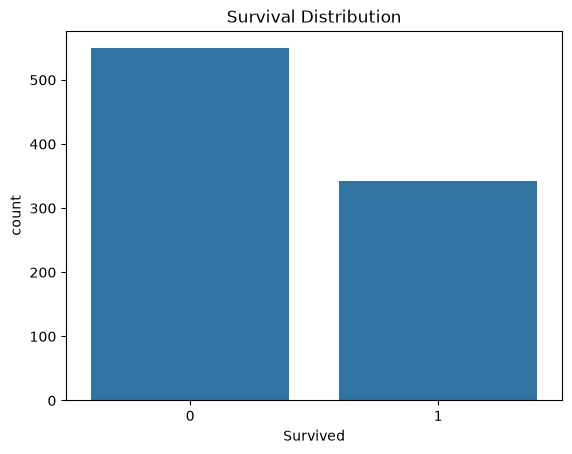

In [7]:
sns.countplot(x="Survived", data=df)

plt.title("Survival Distribution")
plt.show()

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df["Age"].fillna(df["Age"].median(), inplace=True)

df["Embarked"].fillna(
    df["Embarked"].mode()[0], inplace=True
)

/var/folders/xj/k0m7g06133vf7zhcrt6zz78h0000gn/T/ipykernel_72514/3379388991.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Age"].fillna(df["Age"].median(), inplace=True)
/var/folders/xj/k0m7g06133vf7zhcrt6zz78h0000gn/T/ipykernel_72514/3379388991.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or S

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

In [12]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features]
y = df["Survived"]

In [3]:
encoder = LabelEncoder()

X["Sex"] = encoder.fit_transform(X["Sex"])
X["Embarked"] = encoder.fit_transform(X["Embarked"])

NameError: name 'LabelEncoder' is not defined

In [4]:
scaler = StandardScaler()

X[["Age", "Fare"]] = scaler.fit_transform(X[["Age", "Fare"]])

X.head()

NameError: name 'StandardScaler' is not defined

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [17]:
params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=3,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0

In [18]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

In [20]:
class_report = classification_report(y_test, y_pred)

print(class_report)

              precision    recall  f1-score   support

           0       0.81      0.91      0.86       105
           1       0.85      0.69      0.76        74

    accuracy                           0.82       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



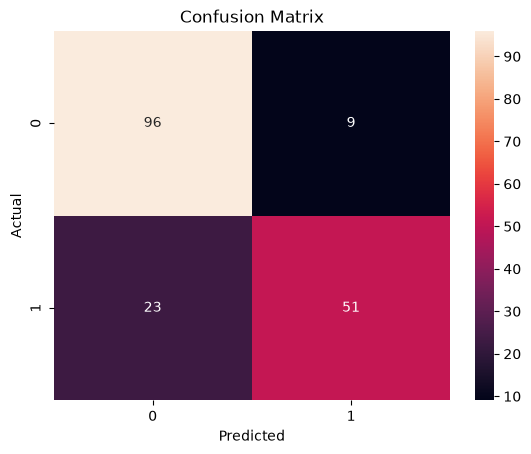

In [21]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

House Price Prediction using Linear Regression

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset 
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [24]:
df.drop_duplicates(inplace=True)

In [25]:
categorical_cols = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus"
]

In [ ]:
encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

X = df.drop("price", axis=1)
y = df['price']

In [27]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [33]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Prediction 
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 979679.6912959906
MSE: 1771751116594.0393
RMSE: 1331071.4167895121
R2 Score: 0.6494754192267795


In [34]:
results = pd.DataFrame({
    "Actual Price": y_test, 
    "Predicted Price": y_pred
})

print(results.head())

     Actual Price  Predicted Price
316       4060000     5.203692e+06
77        6650000     7.257004e+06
360       3710000     3.062829e+06
90        6440000     4.559592e+06
493       2800000     3.332932e+06


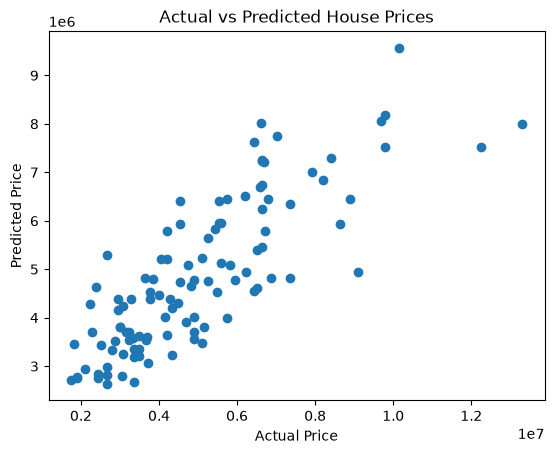

In [35]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

Question 2 — Customer Segmentation using K-Means Clustering (Jupyter Notebook)

In [ ]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [37]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [39]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [40]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


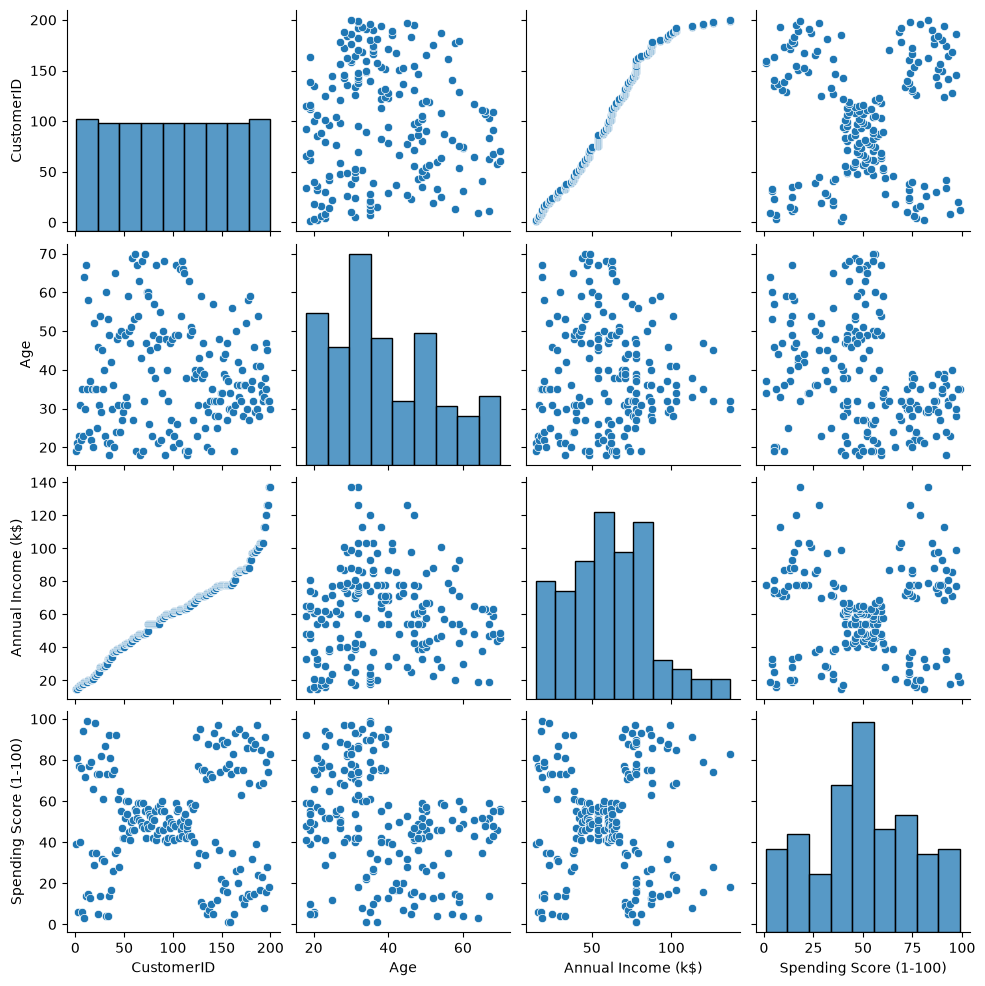

In [41]:
sns.pairplot(df)
plt.show()

In [42]:
df.drop_duplicates(inplace=True)
df.shape 

(200, 5)

In [43]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [44]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [45]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

In [5]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

NameError: name 'KMeans' is not defined

In [6]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

NameError: name 'KMeans' is not defined

In [48]:
df['Clusters'] = clusters 

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Clusters
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


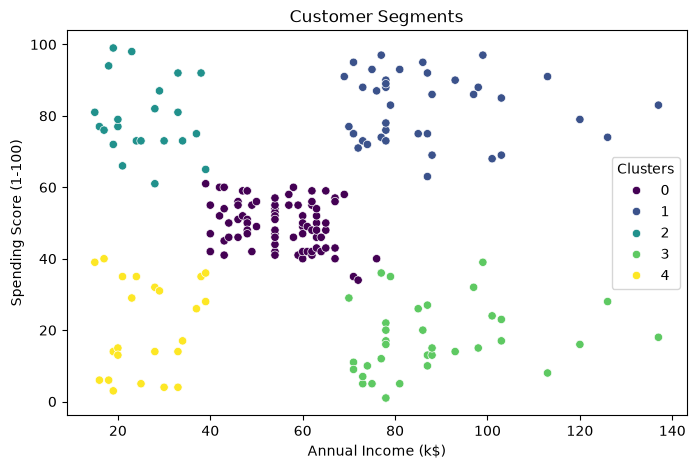

In [50]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)", 
    y = "Spending Score (1-100)",
    hue="Clusters",
    palette="viridis"
)
plt.title("Customer Segments")
plt.show()